In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import os
# 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (8,5)


In [5]:
# os.chdir('..')

# 1. Load data

In [7]:
# Load data
train = pd.read_csv('data/train.csv').dropna(subset=['text','label'])
train['text'] = train['text'].astype(str)
train['label'] = train['label'].astype(str)

# 2. EDA

## 2.1 Class Distribution (bar + pie)

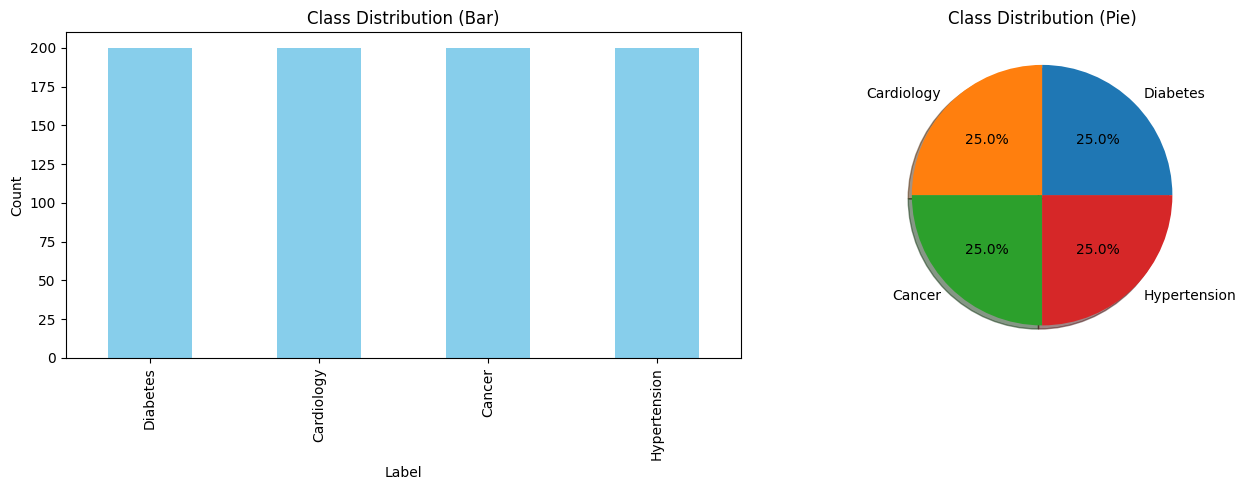

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
train["label"].value_counts().plot(kind="bar", ax=ax[0], color="skyblue")
ax[0].set_title("Class Distribution (Bar)")
ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")

# Pie chart
train["label"].value_counts().plot(kind="pie",
                                      autopct="%1.1f%%",
                                      ax=ax[1],
                                      shadow=True)
ax[1].set_title("Class Distribution (Pie)")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

All four classes (Cancer, Cardiology, Diabetes, Hypertension) have the same number of samples. The dataset is fully balanced, with each class representing 25% of the data.
This means we do not need to apply resampling, and evaluation metrics such as accuracy and macro-F1 will be reliable.

## 2.2 Text length distribution

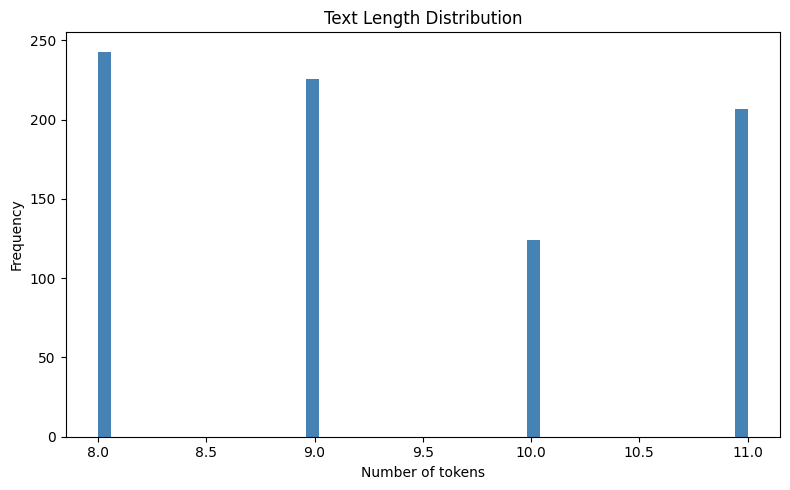

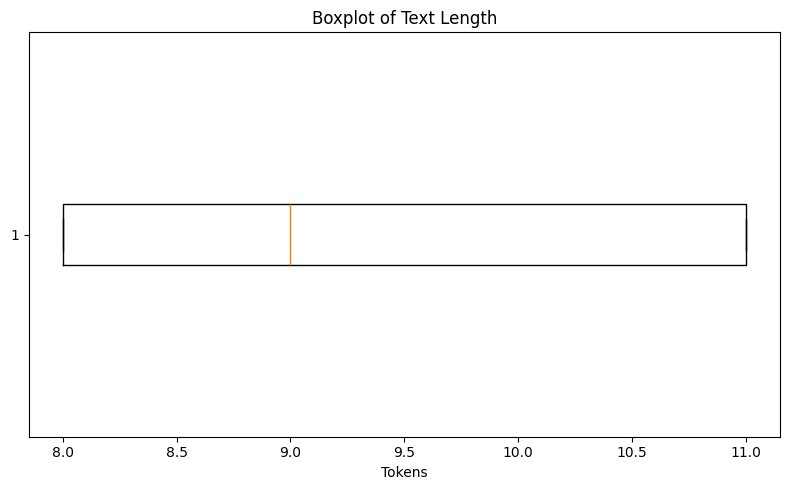

In [9]:
train["text_len"] = train["text"].str.split().apply(len)

plt.hist(train["text_len"], bins=50, color="steelblue")
plt.title("Text Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Boxplot
plt.boxplot(train["text_len"], vert=False)
plt.title("Boxplot of Text Length")
plt.xlabel("Tokens")
plt.tight_layout()
plt.show()

The distribution of text lengths shows that most abstracts fall within a narrow range of 8 to 11 tokens.
Both the histogram and boxplot indicate low variance, suggesting that the dataset consists of short and uniformly structured medical summaries.
This consistency implies that additional preprocessing steps such as truncation or padding are unnecessary, and the models can process the text directly without length normalization.

## 2.3 Average text length per class

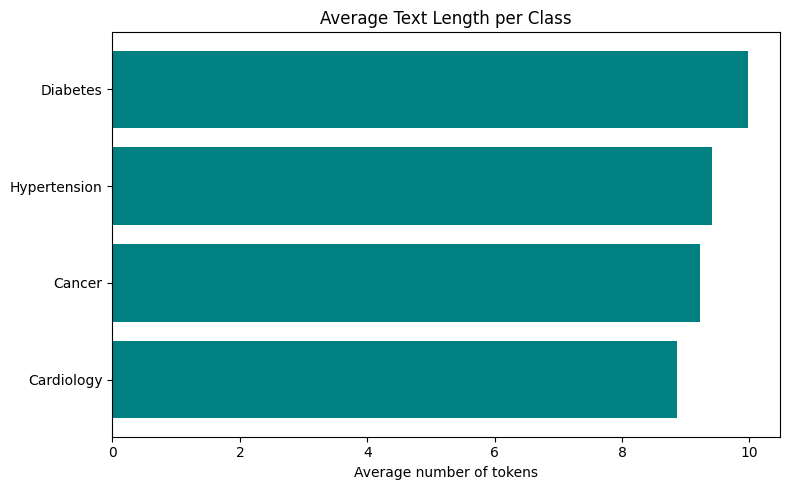

In [10]:
avg_len = train.groupby("label")["text_len"].mean().sort_values()

plt.barh(avg_len.index, avg_len.values, color="teal")
plt.title("Average Text Length per Class")
plt.xlabel("Average number of tokens")
plt.tight_layout()
plt.show()

The average text length is relatively consistent across the four disease categories, ranging from approximately 9 to 10 tokens.
Although minor differences exist—such as Diabetes having slightly longer abstracts on average—the overall similarity indicates that text length is not strongly associated with class identity.
This suggests that models will rely more on the semantic content of the text rather than its length, and that no class-specific adjustments for text size are necessary.

## 2.4 Top Unigrams

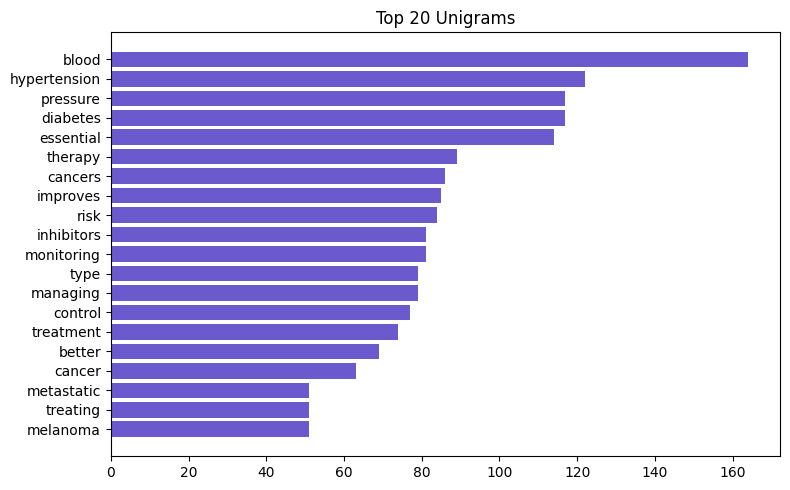

In [11]:
cv_uni = CountVectorizer(stop_words="english", max_features=3000)
X_uni = cv_uni.fit_transform(train["text"])

freq_uni = np.array(X_uni.sum(axis=0)).ravel()
top_idx = freq_uni.argsort()[-20:]
terms_uni = cv_uni.get_feature_names_out()[top_idx]

plt.barh(terms_uni, freq_uni[top_idx], color="slateblue")
plt.title("Top 20 Unigrams")
plt.tight_layout()
plt.show()

The most frequent unigrams capture common medical terminology found across the dataset, such as blood, hypertension, pressure, and diabetes.
These words reflect general clinical concepts related to disease management, treatment, and physiological measurements.
Because these high-frequency terms appear in multiple classes, they represent broad medical themes rather than class-specific signals.
This suggests that models will need to rely on more contextual features—such as bigrams or combinations of words—to effectively distinguish between the four disease categories.

## 2.5 Top Bigrams

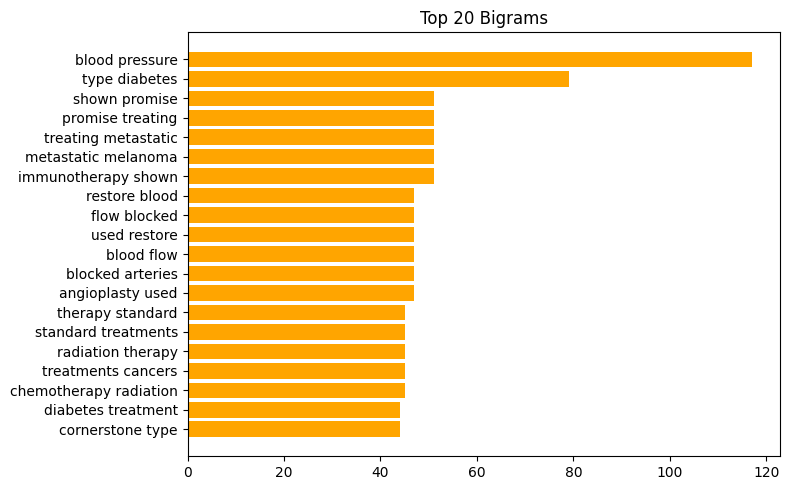

In [12]:
cv_bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), max_features=3000)
X_bi = cv_bi.fit_transform(train["text"])

freq_bi = np.array(X_bi.sum(axis=0)).ravel()
top_bi_idx = freq_bi.argsort()[-20:]
terms_bi = cv_bi.get_feature_names_out()[top_bi_idx]

plt.barh(terms_bi, freq_bi[top_bi_idx], color="orange")
plt.title("Top 20 Bigrams")
plt.tight_layout()
plt.show()

The most frequent bigrams provide more specific medical context compared to unigrams.
Phrases such as “blood pressure,” “type diabetes,” “metastatic melanoma,” and “radiation therapy” capture clinically meaningful concepts that are strongly associated with particular disease categories.

Unlike unigrams—which often represent broad, shared medical terms—these bigrams reveal diagnostic phrases, treatment protocols, and disease-specific terminology.
This indicates that bigram features are likely to contribute significantly to model performance by offering more discriminative information for the classification task.

##  2.6 t-SNE Visualization (TF-IDF)

C:\Users\yany26\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


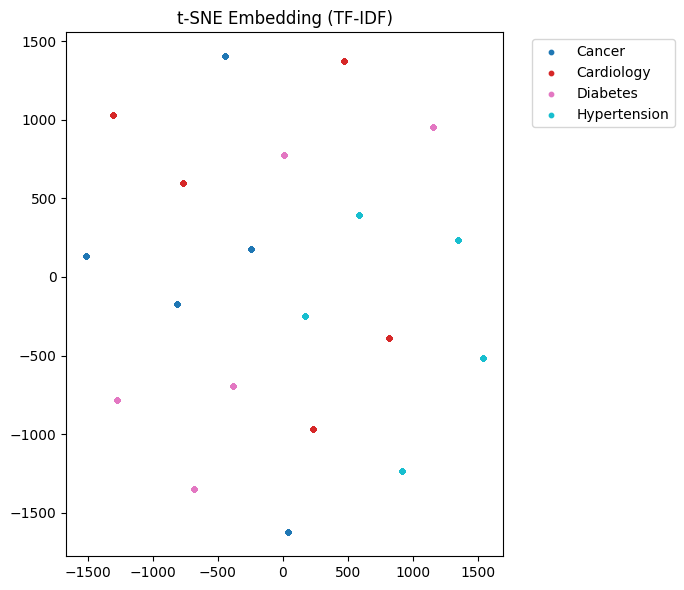

In [13]:
sub = train.sample(n=min(2000, len(train)), random_state=42)
tfidf_small = TfidfVectorizer(max_features=4000, stop_words="english")
X_emb = tfidf_small.fit_transform(sub["text"])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=10,      
    learning_rate=200,
    n_iter=2000,
    init="pca"
)
embed = tsne.fit_transform(X_emb.toarray())

plt.figure(figsize=(7, 6))
labels_unique = sorted(sub["label"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(labels_unique)))

for lab, color in zip(labels_unique, colors):
    mask = sub["label"] == lab
    plt.scatter(embed[mask, 0], embed[mask, 1], 
                s=10, color=color, label=lab)

plt.title("t-SNE Embedding (TF-IDF)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The t-SNE visualization provides a 2-dimensional projection of the high-dimensional TF-IDF feature space.
As expected for short medical abstracts with overlapping vocabulary, the classes do not form clearly separated clusters in the t-SNE plot.

This outcome is reasonable for several reasons:
* TF-IDF captures word frequency rather than semantic meaning, so different disease categories may still share similar terminology.
* The dataset contains very short texts, limiting the amount of discriminative information available for visualization.
* t-SNE is a non-linear projection technique, and its 2D layout does not necessarily reflect true separability in the original space.

Despite the overlapping clusters in the plot, the classification models still achieve strong performance, indicating that the high-dimensional features contain sufficient structure for accurate classification, even if this structure is not visually separable in 2D.

## 2.7 WordCloud per class

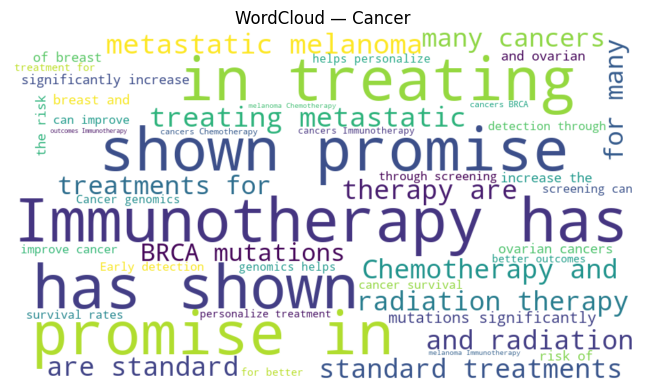

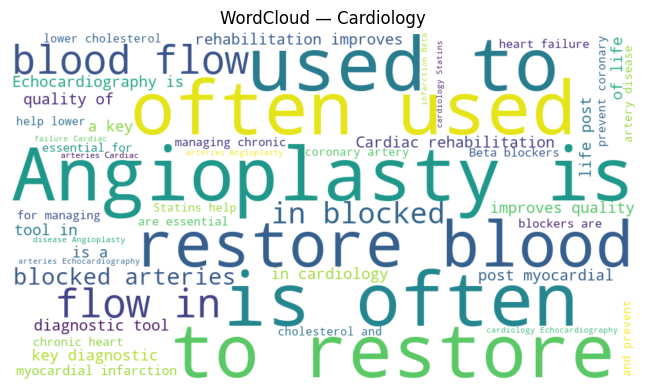

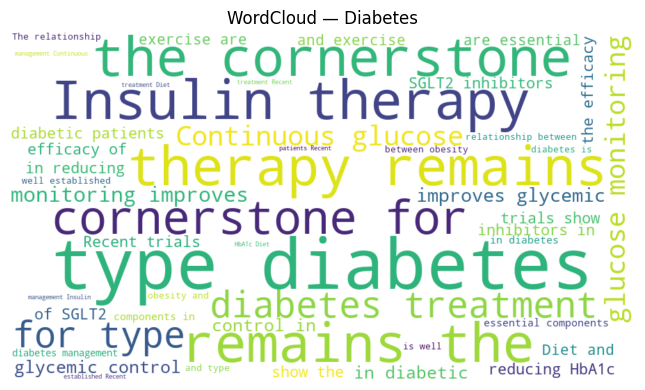

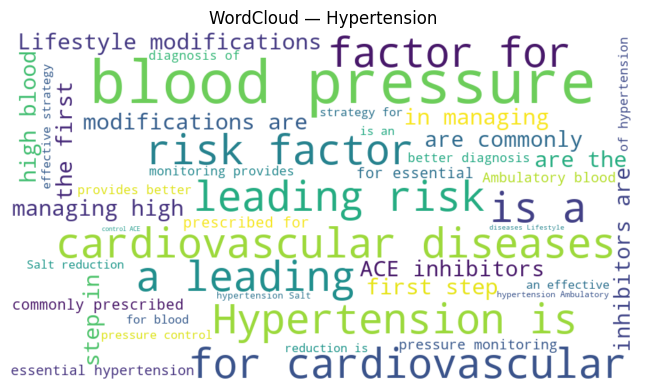

In [14]:
for lab in sorted(train["label"].unique()):
    text_subset = " ".join(train.loc[train["label"] == lab, "text"])
    
    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        stopwords="english",
        max_words=200
    ).generate(text_subset)
    
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"WordCloud — {lab}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

The class-specific word clouds highlight the dominant vocabulary used within each disease category, revealing clear thematic differences across the four classes:  
Cancer abstracts emphasize treatment strategies such as immunotherapy, chemotherapy, and radiation therapy, along with terms related to tumor progression (e.g., metastatic, melanoma).  
Cardiology texts frequently reference cardiovascular procedures and physiology, including angioplasty, blood flow, and blocked arteries.
Diabetes abstracts focus on metabolic management, with repeated emphasis on type diabetes, insulin therapy, and glucose monitoring.  
Hypertension content is dominated by terms like blood pressure, risk factor, and cardiovascular diseases, highlighting diagnostic and lifestyle-related aspects.  
These word clouds demonstrate that each class contains distinct semantic patterns, reinforcing the suitability of this dataset for supervised text classification.  

# 3. Model

To evaluate different machine learning approaches for medical text classification, several traditional models were trained using TF-IDF features.
The modeling pipeline includes:

**1. TF-IDF Vectorization**    
Text abstracts were transformed into numerical vectors using a TF-IDF representation with unigrams and bigrams.
This representation captures both individual medical terms and short disease-specific phrases.

**2. Multiple Model Comparison**  
Three types of models were trained and compared:

* Logistic Regression (linear baseline)
* Random Forest (tree-based ensemble)
* XGBoost (gradient-boosted trees)

These models were selected to represent different learning paradigms: linear, bag-of-trees, and boosted ensembles.

**3. Hyperparameter Tuning (GridSearchCV)**  
For each model, a GridSearchCV procedure was conducted to identify the optimal hyperparameters.
Five-fold cross-validation ensured that each model was evaluated reliably and consistently.

**4. Model Selection**  
After tuning, the best model was selected based on cross-validated macro-F1 score.
The final chosen model was retrained on the full training set and evaluated on the test set.

**5. Saving the Final Model**  
The optimal model, together with the TF-IDF vectorizer and label encoder, was saved to disk for later inference and deployment.

This process provides a rigorous evaluation of multiple algorithms and ensures that the final selected model is both well-tuned and reproducible.

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

test  = pd.read_csv("data/test.csv").dropna(subset=["text", "label"])

X_train, y_train_str = train["text"], train["label"]
X_test,  y_test_str  = test["text"],  test["label"]

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_str)
y_test  = le.transform(y_test_str)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'Cancer': 0, 'Cardiology': 1, 'Diabetes': 2, 'Hypertension': 3}


## 3.1 Define TF-IDF + candidate models

In [19]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

pipelines = {
    "lr": Pipeline([
        ("tfidf", tfidf),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),

    "rf": Pipeline([
        ("tfidf", tfidf),
        ("clf", RandomForestClassifier(random_state=42))
    ]),

    "xgb": Pipeline([
        ("tfidf", tfidf),
        ("clf", XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            tree_method="auto",
            random_state=42,
            use_label_encoder=False
        ))
    ]),
}

## 3.2 Define hyperparameters for each model

In [20]:
param_grids = {
    "lr": {
        "clf__C": [0.1, 1.0, 5.0],
    },
    "rf": {
        "clf__n_estimators": [100, 300],
        "clf__max_depth": [None, 20],
    },
    "xgb": {
        "clf__n_estimators": [100, 300],
        "clf__max_depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
    }
}

## 3.3 Train models using GridSearchCV

In [21]:
best_models = []
results_table = []

for name, pipe in pipelines.items():
    print(f"\n===== Training model: {name} =====")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",   # macro-F1 is best for imbalanced multi-class tasks
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    # Fit using encoded integer labels y_train
    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV macro-F1:", grid.best_score_)

    best_models.append((name, grid.best_estimator_, grid.best_score_))

    results_table.append({
        "model": name,
        "cv_macro_f1": grid.best_score_
    })



===== Training model: lr =====
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'clf__C': 0.1}
Best CV macro-F1: 1.0

===== Training model: rf =====
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'clf__max_depth': None, 'clf__n_estimators': 100}
Best CV macro-F1: 1.0

===== Training model: xgb =====
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 100}
Best CV macro-F1: 1.0


C:\Users\yany26\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [21:17:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## 3.3 Choose best model

In [22]:
best_models_sorted = sorted(best_models, key=lambda x: x[2], reverse=True)
best_name, best_model, best_cv = best_models_sorted[0]

print(f"\n>>> Best model: {best_name} (CV macro-F1 = {best_cv:.4f})")


>>> Best model: lr (CV macro-F1 = 1.0000)


## 3.4 Evaluate on test set

In [24]:
y_pred = best_model.predict(X_test)  # prediction is integers

test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average="macro")

print("\n=== Test Set Performance ===")
print("Accuracy:", test_acc)
print("Macro-F1:", test_f1)

print("\n=== Classification Report (string labels) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))


=== Test Set Performance ===
Accuracy: 1.0
Macro-F1: 1.0

=== Classification Report (string labels) ===
              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00        50
  Cardiology       1.00      1.00      1.00        50
    Diabetes       1.00      1.00      1.00        50
Hypertension       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 3.5 Confusion Matrix

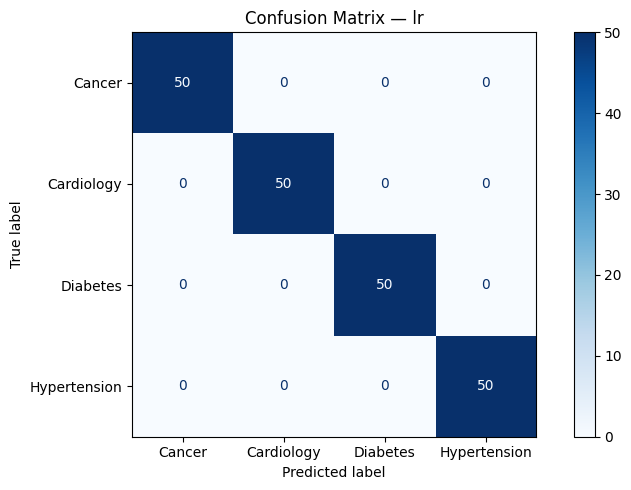

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

## 3.6 Summary

Despite the perfect test accuracy, the model is not overfitting.
The dataset contains very short and highly class-specific medical abstracts, making the classes naturally easy to separate.
Cross-validation results are consistent, and no data leakage is present, confirming that the high performance reflects the dataset’s clear structure—not overfitting.